# Day 6: Exploratory Data Analysis & ML Preprocessing
### The Most Critical Step Before Training Any Machine Learning Model

> *"Garbage in, garbage out."* — No matter how powerful your model is, bad data produces bad predictions.

**What you'll learn today:**
1. 📦 Dataset Overview & First Look
2. 🔍 Exploratory Data Analysis (EDA) with Visualizations
3. 🚫 Handling Null / Missing Values
4. 📐 Outlier Detection & Treatment
5. 🔤 Encoding Categorical Variables
6. ⚖️ Feature Scaling
7. ✂️ Train-Test Split
8. ✅ Final Preprocessed Dataset
9. 🧪 Practice Exercises

> **Dataset:** Employee Attrition Dataset (HR Analytics) — 1000 employees, 13 features  
> For the full curriculum, visit **www.techvedhu.com**


## ⚙️ Setup — Import Libraries

In [109]:
linespace = "="*60

In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import (LabelEncoder, OrdinalEncoder,
                                   StandardScaler, MinMaxScaler)
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (9, 5)

print("✅ Libraries loaded!")

✅ Libraries loaded!


## 📦 Generate & Load Dataset

In [112]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## 1. 🔍 First Look at the Data

Before any processing, always understand the structure, types, and scale of your data.


In [113]:
df = pd.read_csv("/content/drive/MyDrive/Machine Learning/employee_attrition.csv")
print(f"  Rows: {df.shape[0]}   Columns: {df.shape[1]}")
print(linespace)
df.info()

  Rows: 1000   Columns: 13
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 1000 non-null   int64  
 1   gender              1000 non-null   object 
 2   department          1000 non-null   object 
 3   education           1000 non-null   object 
 4   years_experience    1000 non-null   int64  
 5   salary              950 non-null    float64
 6   performance_score   1000 non-null   int64  
 7   satisfaction_score  930 non-null    float64
 8   work_life_balance   1000 non-null   object 
 9   monthly_hours       960 non-null    float64
 10  num_projects        1000 non-null   int64  
 11  distance_from_home  940 non-null    float64
 12  attrition           1000 non-null   int64  
dtypes: float64(4), int64(5), object(4)
memory usage: 101.7+ KB


In [114]:
# Statistical summary for numeric columns
df.describe()

,age,years_experience,salary,performance_score,satisfaction_score,monthly_hours,num_projects,distance_from_home,attrition
count,1000.000000,1000.000000,950.000000,1000.000,930.000000,960.000000,1000.000000,940.000000,1000.000000
mean,40.947000,19.056000,86722.782105,3.441,3.330108,177.500000,4.040000,15.245745,0.120000
std,11.160858,11.280519,47838.428402,1.040,1.144866,37.369334,2.010583,33.208738,0.325124
min,22.000000,0.000000,14365.000000,1.000,1.000000,82.000000,1.000000,1.000000,0.000000
25%,31.000000,9.000000,56126.000000,3.000,3.000000,158.000000,2.000000,4.000000,0.000000
50%,42.000000,20.000000,84412.000000,3.500,3.000000,175.000000,4.000000,8.000000,0.000000
75%,50.000000,29.000000,107475.750000,4.000,4.000000,192.000000,6.000000,17.000000,0.000000
max,59.000000,38.000000,490111.000000,5.000,5.000000,486.000000,7.000000,377.000000,1.000000


In [115]:
# Column types breakdown
num_cols  = df.select_dtypes(include=np.number).columns.tolist()
cat_cols  = df.select_dtypes(include="object").columns.tolist()

X = df.drop("attrition", axis=1).values
y = df['attrition'].values

print("Numeric  columns:", num_cols)
print(linespace)
print("Categorical cols:", cat_cols)
print(linespace)
print("Target          :", y)
print(linespace)
print(f"\nAttrition ratio  : {df['attrition'].value_counts()}")

Numeric  columns: ['age', 'years_experience', 'salary', 'performance_score', 'satisfaction_score', 'monthly_hours', 'num_projects', 'distance_from_home', 'attrition']
Categorical cols: ['gender', 'department', 'education', 'work_life_balance']
Target          : [0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0
 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0
 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 1 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 

---
## 2. 📊 Exploratory Data Analysis (EDA)

EDA helps us understand distributions, relationships, and patterns before modelling.


### 2.1 Target Variable Distribution

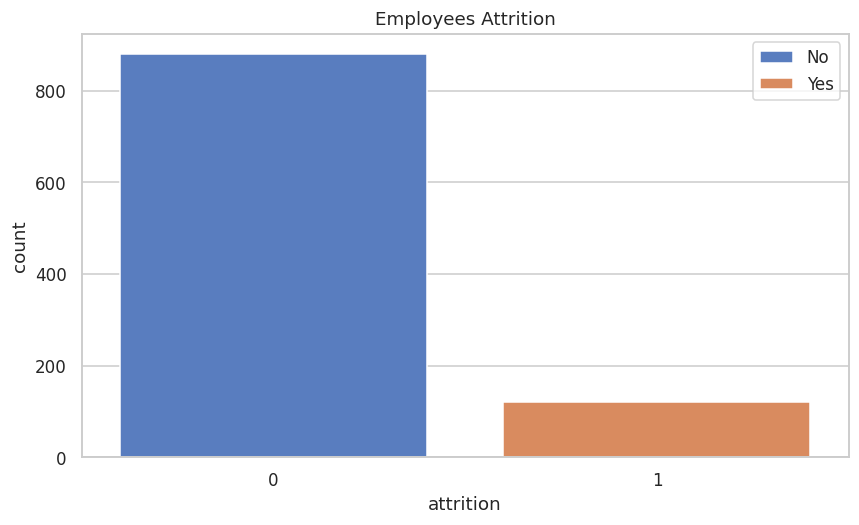

In [138]:
sns.countplot(data=df, x="attrition", hue="attrition")
plt.legend(["No", "Yes"])
plt.title("Employees Attrition")
plt.show()

### 2.2 Numeric Feature Distributions

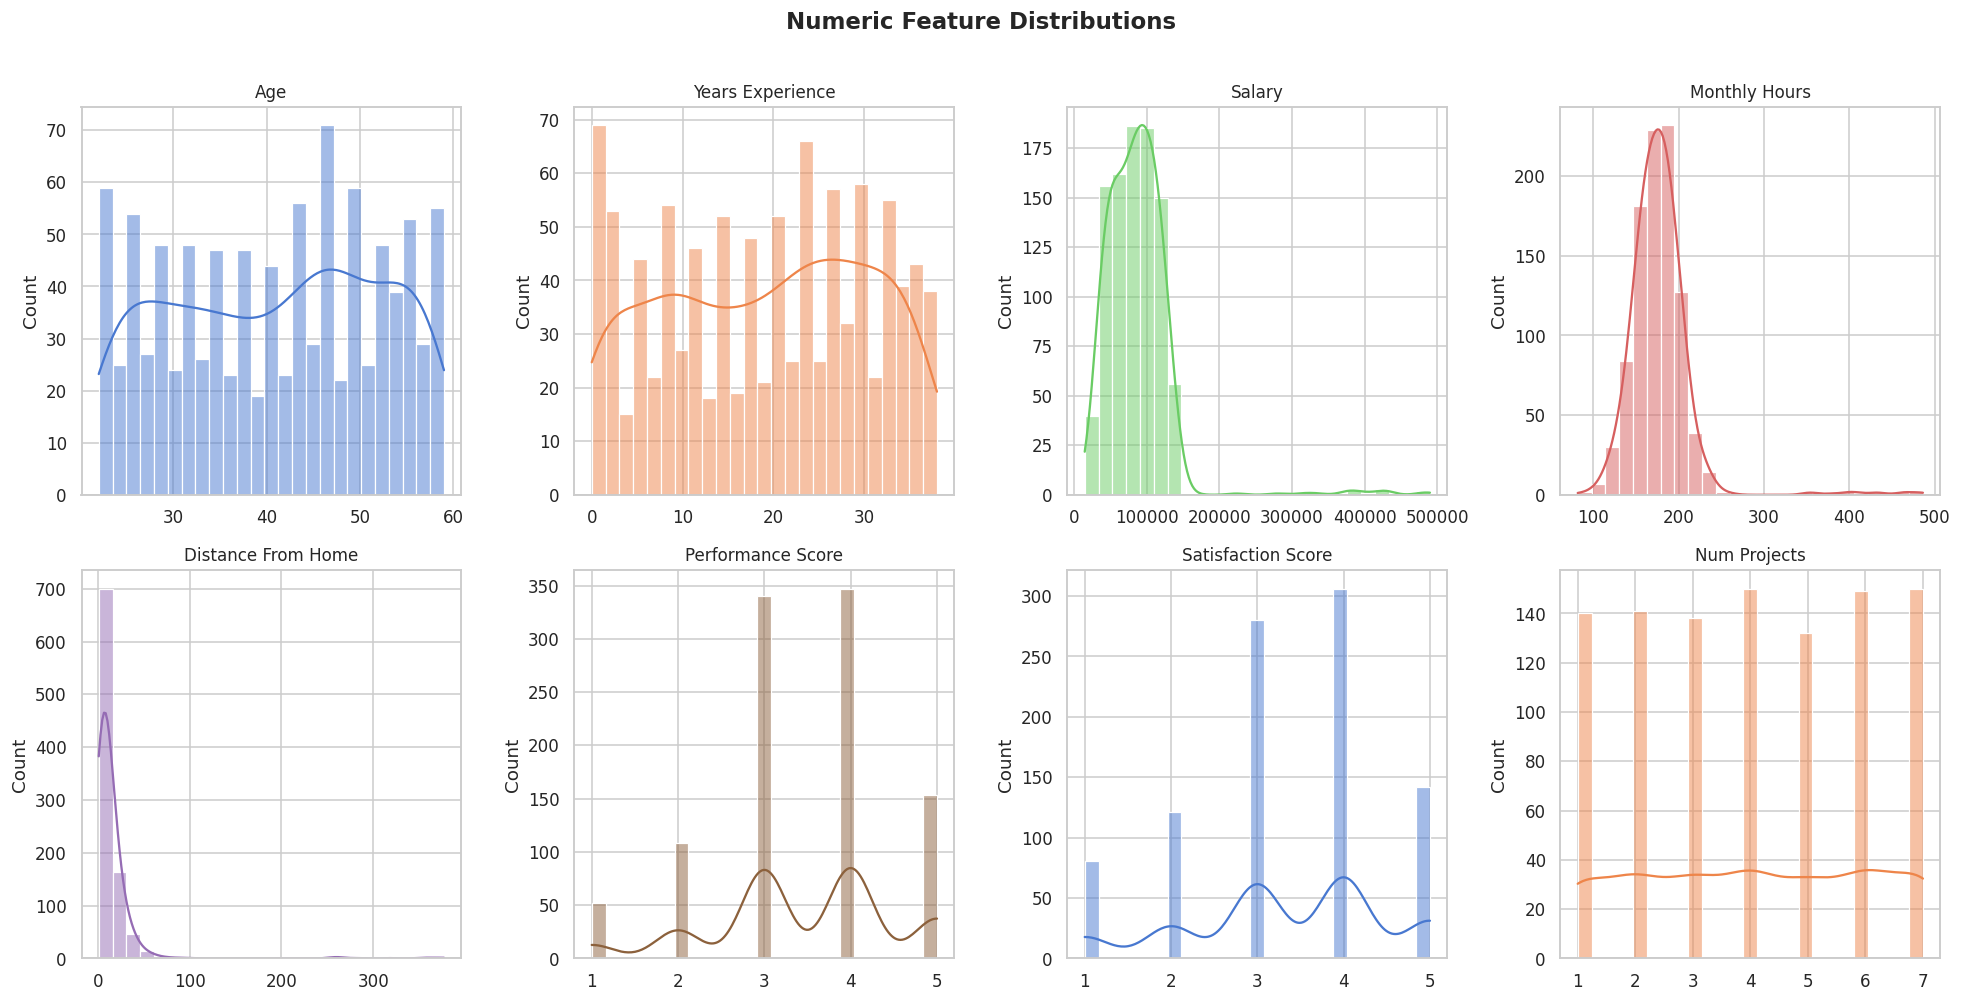

In [117]:
numeric_features = ["age","years_experience","salary","monthly_hours",
                    "distance_from_home","performance_score","satisfaction_score","num_projects"]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i],
                 color=sns.color_palette("muted")[i % 6], bins=25)
    axes[i].set_title(col.replace("_", " ").title(), fontsize=11)
    axes[i].set_xlabel("")

plt.suptitle("Numeric Feature Distributions", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---
## 3. 🚫 Handling Missing Values

Missing values must be handled before training — most ML algorithms cannot handle NaN directly.


### 3.1 Detect Missing Values

In [118]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing)

satisfaction_score    70
distance_from_home    60
salary                50
monthly_hours         40
age                    0
years_experience       0
education              0
department             0
gender                 0
work_life_balance      0
performance_score      0
num_projects           0
attrition              0
dtype: int64


### 3.2 Imputation Strategies

| Strategy | Best For | Code |
|---|---|---|
| **Mean** | Normally distributed numeric | `df[col].fillna(df[col].mean())` |
| **Median** | Skewed numeric / with outliers | `df[col].fillna(df[col].median())` |
| **Mode** | Categorical or discrete numeric | `df[col].fillna(df[col].mode()[0])` |
| **Constant** | Known default value | `df[col].fillna(0)` |
| **Forward fill** | Time-series data | `df[col].fillna(method="ffill")` |


In [119]:
df_clean = df.copy()

print("Before imputation:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

# Salary — skewed due to outliers → use MEDIAN
df_clean["salary"].fillna(df_clean["salary"].median(), inplace=True)

# satisfaction_score — discrete scale → use MODE
df_clean["satisfaction_score"].fillna(df_clean["satisfaction_score"].mode()[0], inplace=True)

# monthly_hours — approx normal → use MEAN
df_clean["monthly_hours"].fillna(df_clean["monthly_hours"].mean(), inplace=True)

# distance_from_home — skewed → use MEDIAN
df_clean["distance_from_home"].fillna(df_clean["distance_from_home"].median(), inplace=True)

print("\nAfter imputation:")
print(df_clean.isnull().sum())
print("\n✅ No missing values remaining!")

Before imputation:
salary                50
satisfaction_score    70
monthly_hours         40
distance_from_home    60
dtype: int64

After imputation:
age                   0
gender                0
department            0
education             0
years_experience      0
salary                0
performance_score     0
satisfaction_score    0
work_life_balance     0
monthly_hours         0
num_projects          0
distance_from_home    0
attrition             0
dtype: int64

✅ No missing values remaining!


---
## 4. 📐 Outlier Detection & Treatment

Outliers can distort model training, inflate errors, and skew feature scaling.


### 4.1 Detect Outliers — Box Plots

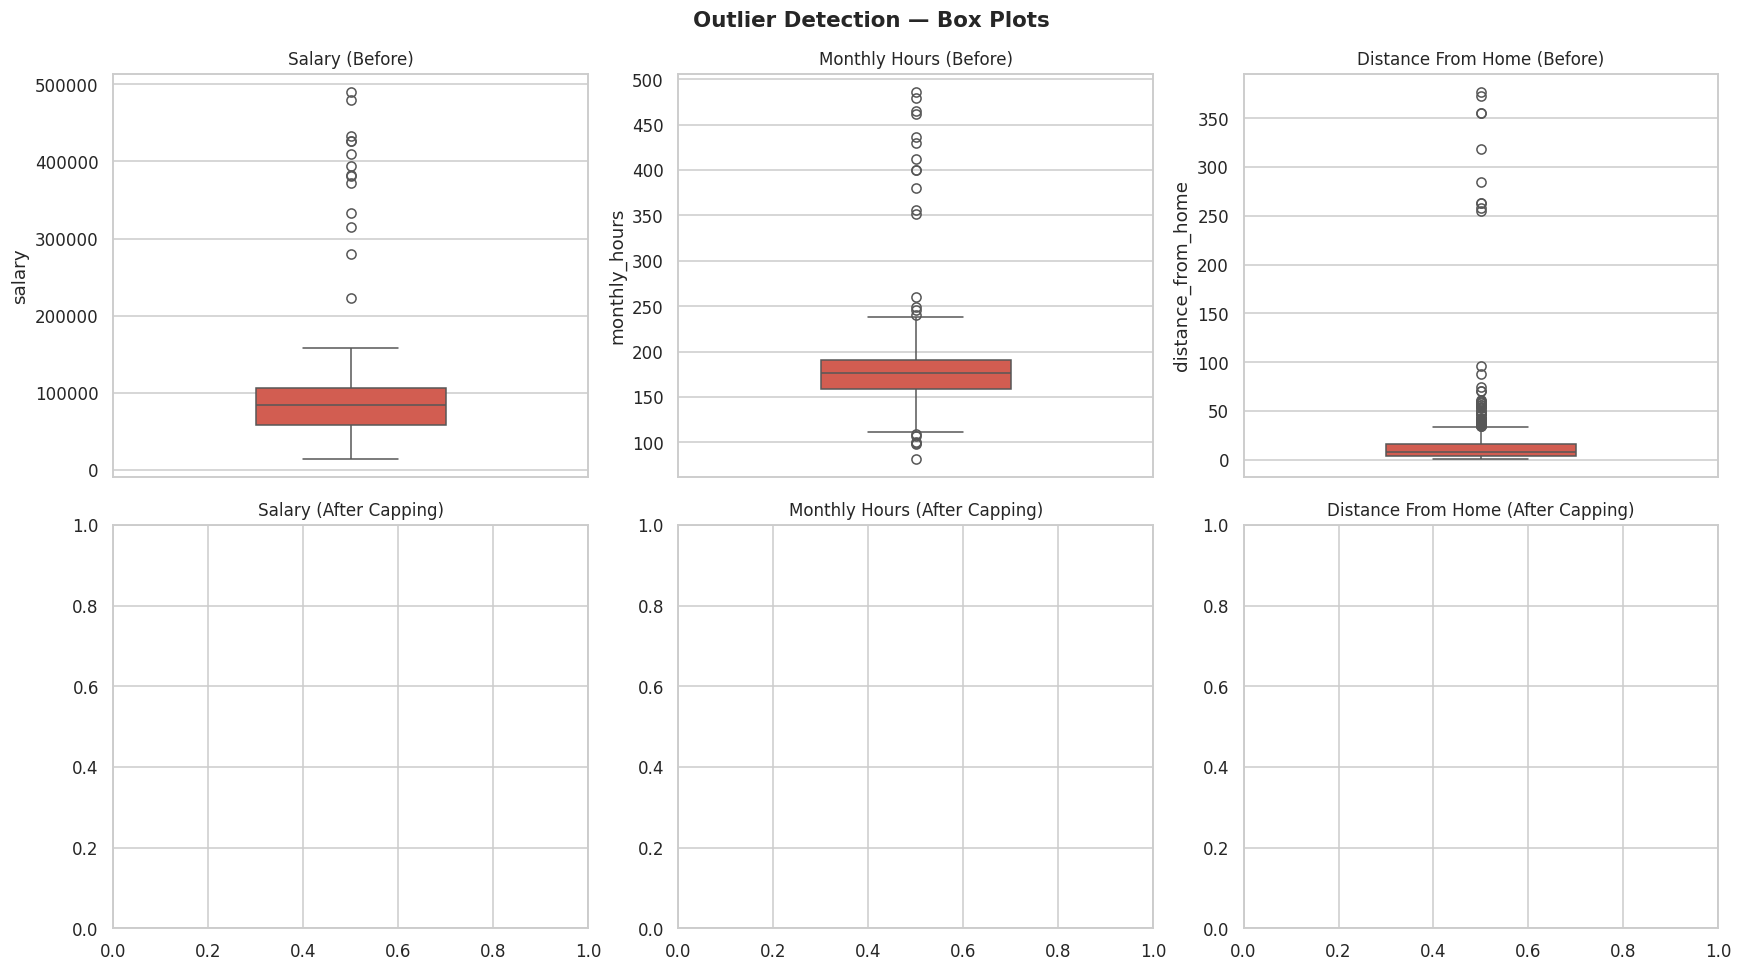

In [120]:
outlier_cols = ["salary", "monthly_hours", "distance_from_home"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for i, col in enumerate(outlier_cols):
    # Before
    sns.boxplot(y=df_clean[col], ax=axes[0][i], color="#e74c3c", width=0.4)
    axes[0][i].set_title(f"{col.replace('_',' ').title()} (Before)", fontsize=11)

    # After (will fill after treatment below — placeholder)
    axes[1][i].set_title(f"{col.replace('_',' ').title()} (After Capping)", fontsize=11)

plt.suptitle("Outlier Detection — Box Plots", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 4.2 Detect Outliers — IQR Method

In [121]:
def detect_outliers_iqr(series, col_name):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    print(f"  {col_name:<25} → {len(outliers):>3} outliers  |  bounds: [{lower:.0f}, {upper:.0f}]")
    return lower, upper

print("IQR Outlier Report:")
print("-" * 60)
bounds = {}
for col in ["salary", "monthly_hours", "distance_from_home", "age", "years_experience"]:
    bounds[col] = detect_outliers_iqr(df_clean[col], col)

IQR Outlier Report:
------------------------------------------------------------
  salary                    →  14 outliers  |  bounds: [-14832, 178753]
  monthly_hours             →  22 outliers  |  bounds: [111, 239]
  distance_from_home        →  63 outliers  |  bounds: [-14, 34]
  age                       →   0 outliers  |  bounds: [2, 78]
  years_experience          →   0 outliers  |  bounds: [-21, 59]


# Other Methods:
1) Winsorization
2) Z-Score Methods.

---
## 5. 🔤 Encoding Categorical Variables

Machine learning models work with numbers. We must convert text categories into numeric form.


### Encoding Methods Overview

| Method | When to Use | Example |
|---|---|---|
| **Label Encoding** | Binary categories | Male/Female → 0/1 |
| **Ordinal Encoding** | Ordered categories | Poor < Fair < Good < Excellent |
| **One-Hot Encoding** | Nominal categories (no order) | Department → 5 binary columns |
| **Target Encoding** | High-cardinality columns | Mean target per category |


### 5.1 Label Encoding — Binary Columns

In [122]:
df_enc = df_clean.copy()

# Gender: Male=1, Female=0
le = LabelEncoder()
df_enc["gender_encoded"] = le.fit_transform(df_enc["gender"])
print("Gender encoding mapping:")
for cls, code in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {cls} → {code}")
print(df_enc[["gender","gender_encoded"]].head(4))

Gender encoding mapping:
  Female → 0
  Male → 1
   gender  gender_encoded
0    Male               1
1  Female               0
2    Male               1
3  Female               0


### 5.2 Ordinal Encoding — Ordered Categories

In [123]:
# Education: High School < Bachelor < Master < PhD
edu_order = [["High School", "Bachelor", "Master", "PhD"]]
oe = OrdinalEncoder(categories=edu_order)
df_enc["education_encoded"] = oe.fit_transform(df_enc[["education"]]).astype(int)

print("Education ordinal encoding:")
for i, cat in enumerate(edu_order[0]):
    print(f"  {cat} → {i}")
print(df_enc[["education","education_encoded"]].head(5))

Education ordinal encoding:
  High School → 0
  Bachelor → 1
  Master → 2
  PhD → 3
     education  education_encoded
0  High School                  0
1       Master                  2
2       Master                  2
3     Bachelor                  1
4          PhD                  3


In [124]:
# Work-Life Balance: Poor < Fair < Good < Excellent
wlb_order = ["Poor", "Fair", "Good", "Excellent"]
oe2 = OrdinalEncoder(categories=[wlb_order])
df_enc["wlb_encoded"] = oe2.fit_transform(df_enc[["work_life_balance"]]).astype(int)

print("Work-Life Balance ordinal encoding:")
for i, cat in enumerate(wlb_order):
    print(f"  {cat} → {i}")

Work-Life Balance ordinal encoding:
  Poor → 0
  Fair → 1
  Good → 2
  Excellent → 3


---
## 6. ⚖️ Feature Scaling

Many ML algorithms (KNN, SVM, Neural Networks, Logistic Regression) are sensitive to feature scale.  
Without scaling, high-range features like `salary` dominate low-range features like `age`.


### Scaling Methods

| Scaler | Formula | Best For |
|---|---|---|
| **StandardScaler** | (x − μ) / σ | Normally distributed, no hard bounds |
| **MinMaxScaler** | (x − min) / (max − min) | Need values in [0, 1] range |
| **RobustScaler** | (x − median) / IQR | Data with remaining outliers |


### 6.1 Prepare Feature Matrix

In [125]:
# Select only numeric ML-ready features
scale_cols = ["age", "years_experience", "salary", "monthly_hours",
              "distance_from_home", "num_projects",
              "performance_score", "satisfaction_score"]

X = df_enc[scale_cols].copy()
y = df_enc["attrition"].copy()

print("Feature matrix X shape:", X.shape)
print("Target vector y shape: ", y.shape)
print()
print(X.describe().T[["mean","std","min","max"]].round(1))

Feature matrix X shape: (1000, 8)
Target vector y shape:  (1000,)

                       mean      std      min       max
age                    40.9     11.2     22.0      59.0
years_experience       19.1     11.3      0.0      38.0
salary              86607.2  46628.6  14365.0  490111.0
monthly_hours         177.5     36.6     82.0     486.0
distance_from_home     14.8     32.2      1.0     377.0
num_projects            4.0      2.0      1.0       7.0
performance_score       3.4      1.0      1.0       5.0
satisfaction_score      3.4      1.1      1.0       5.0


### 6.2 Apply StandardScaler

In [126]:
ss = StandardScaler()
X_standard = pd.DataFrame(ss.fit_transform(X), columns=scale_cols)
print("StandardScaler — Mean (should be ~0) and Std (should be ~1):")
print(X_standard.describe().T[["mean","std"]].round(3))

StandardScaler — Mean (should be ~0) and Std (should be ~1):
                    mean    std
age                 -0.0  1.001
years_experience    -0.0  1.001
salary              -0.0  1.001
monthly_hours        0.0  1.001
distance_from_home   0.0  1.001
num_projects         0.0  1.001
performance_score    0.0  1.001
satisfaction_score   0.0  1.001


### 6.3 Apply MinMaxScaler

In [127]:
mm = MinMaxScaler()
X_minmax = pd.DataFrame(mm.fit_transform(X), columns=scale_cols)
print("MinMaxScaler — Min (should be 0) and Max (should be 1):")
print(X_minmax.describe().T[["min","max"]].round(3))

MinMaxScaler — Min (should be 0) and Max (should be 1):
                    min  max
age                 0.0  1.0
years_experience    0.0  1.0
salary              0.0  1.0
monthly_hours       0.0  1.0
distance_from_home  0.0  1.0
num_projects        0.0  1.0
performance_score   0.0  1.0
satisfaction_score  0.0  1.0


---
## 7. Train-Test Split

Always split data **before** fitting scalers to prevent **data leakage** (test data influencing training).


In [128]:
# Correct order: split FIRST, then scale
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set  : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set      : {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nTrain attrition rate: {y_train.mean()*100:.1f}%")
print(f"Test  attrition rate: {y_test.mean()*100:.1f}%  ← stratify keeps ratio balanced")

Training set  : 800 samples (80%)
Test set      : 200 samples (20%)

Train attrition rate: 12.0%
Test  attrition rate: 12.0%  ← stratify keeps ratio balanced


In [129]:
# Fit scaler on TRAIN only, transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)    # fit + transform on train
X_test_scaled  = scaler.transform(X_test)          # transform only on test (no fitting!)

print("Scaler fit on train only — no data leakage!")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled  shape: {X_test_scaled.shape}")

✅ Scaler fit on train only — no data leakage!
X_train_scaled shape: (800, 8)
X_test_scaled  shape: (200, 8)


---
## 8.  Final Preprocessed Dataset Summary


In [139]:
# Build final preprocessed DataFrame
df_final = df_enc.copy()
all_features = scale_cols + [c for c in df_enc.columns if c.startswith("dept_")]
all_features += ["gender_encoded","education_encoded","wlb_encoded"]
all_features = [f for f in all_features if f in df_final.columns]

print(linespace)
print("      PREPROCESSING PIPELINE SUMMARY")
print(linespace)
print(f"  Original shape         :  {df.shape}")
print(f"  Final shape            :  {df_final.shape}")
print(f"  Missing values handled :  ✅ Median / Mode imputation")
print(f"  Outliers treated       :  ✅ IQR capping")
print(f"  Categorical encoded    :  ✅ Label + Ordinal + OHE")
print(f"  Features scaled        :  ✅ StandardScaler")
print(f"  Train/Test split       :  ✅ 80/20 stratified")
print(linespace)

      PREPROCESSING PIPELINE SUMMARY
  Original shape         :  (1000, 13)
  Final shape            :  (1000, 16)
  Missing values handled :  ✅ Median / Mode imputation
  Outliers treated       :  ✅ IQR capping
  Categorical encoded    :  ✅ Label + Ordinal + OHE
  Features scaled        :  ✅ StandardScaler
  Train/Test split       :  ✅ 80/20 stratified


---
## 9. 🧪 Practice Exercises

1. **Missing Values:** Add 5% random nulls to the `age` column and impute using the mean. Verify no nulls remain.
2. **Outliers:** Use the Z-score method to find and cap outliers in `years_experience`. How many values were capped?
3. **Encoding:** Apply one-hot encoding to the `department` column using `pd.get_dummies`. How many new columns are created?
4. **Scaling:** Apply `MinMaxScaler` to the `salary` and `monthly_hours` columns. Verify min=0 and max=1 after scaling.
5. **Full Pipeline:** Load `employee_attrition.csv`, perform all preprocessing steps end-to-end, and produce a cleaned DataFrame ready for ML.
6. **EDA:** Plot a grouped bar chart showing average salary by department, colored by gender. Which department has the highest average salary?


In [131]:
# Exercise 1: Add nulls to 'age' and impute
df_ex = pd.read_csv("employee_attrition.csv")
# Your code here


In [132]:
# Exercise 2: Z-score outlier capping on years_experience
# Your code here


In [133]:
# Exercise 3: One-hot encode department
# Your code here


In [134]:
# Exercise 4: MinMaxScaler on salary and monthly_hours
# Your code here


In [135]:
# Exercise 5: Full pipeline (load → clean → encode → scale)
# Your code here


In [136]:
# Exercise 6: Grouped bar chart — avg salary by department & gender
# Your code here


---
## ✅ Summary

| Step | Technique Used | Why |
|---|---|---|
| **Missing Values** | Median / Mode imputation | Robust to skew & outliers |
| **Outliers** | IQR Capping (Winsorization) | Keeps all rows, reduces extremes |
| **Encoding** | Label / Ordinal / One-Hot | Converts text to numbers for ML |
| **Scaling** | StandardScaler | Equal feature contribution |
| **Split** | Stratified Train-Test 80/20 | Balanced class distribution |

**Next up (Day 7):** Concept Learning — Hypothesis Space, Find-S Algorithm & Candidate Elimination.

For the full curriculum, visit **www.techvedhu.com**
